<a href="https://colab.research.google.com/github/jusilva1994/deteccao-de-anomalias/blob/main/Deteccao_de_anomalias_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Classificação desbalanceada

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

# Separar features e target
X = df.drop("Class", axis=1)  # todas as colunas menos 'Class'
y = df["Class"]               # coluna alvo (0 = legítimo, 1 = fraude)

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinar modelo simples
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)

# Avaliar métricas
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))


Acurácia: 0.9992743700478681
Precisão: 0.87
Recall: 0.6397058823529411
F1-Score: 0.7372881355932204


Feature Engineering

In [ ]:
import pandas as pd
import numpy as np

# Carregar dataset
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

# Feature Engineering

# 1. Criar uma feature de valor log-transformado (reduz impacto de valores muito altos)
df["Amount_log"] = np.log1p(df["Amount"])

# 2. Criar uma feature binária: transações de valor alto
df["High_Amount"] = (df["Amount"] > 200).astype(int)

# 3. Criar uma feature temporal: hora aproximada da transação
df["Hour"] = (df["Time"] // 3600) % 24

# 4. Criar uma feature de transações acumuladas por hora
df["Transactions_per_hour"] = df.groupby("Hour")["Hour"].transform("count")

# Visualizar novas colunas
df[["Amount", "Amount_log", "High_Amount", "Hour", "Transactions_per_hour"]].head()


,Amount,Amount_log,High_Amount,Hour,Transactions_per_hour
0,149.62,5.014760,0,0.0,7695
1,2.69,1.305626,0,0.0,7695
2,378.66,5.939276,1,0.0,7695
3,123.50,4.824306,0,0.0,7695
4,69.99,4.262539,0,0.0,7695


Logistic Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

# Features e target
X = df.drop("Class", axis=1)
y = df["Class"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo com balanceamento de classes

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000, class_weight="balanced")
model.fit(X_train_scaled, y_train)

# Coeficientes
coef = model.coef_[0]
features = X.columns

# Mostrar coeficientes ordenados
importance = pd.DataFrame({"Feature": features, "Coeficiente": coef})
importance = importance.sort_values(by="Coeficiente", ascending=False)

print(importance.head(10))   # Top 10 variáveis que aumentam chance de fraude
print(importance.tail(10))   # Top 10 variáveis que reduzem chance de fraude


   Feature  Coeficiente
29  Amount     1.781359
1       V1     1.532663
4       V4     1.295515
5       V5     1.006635
22     V22     0.556531
2       V2     0.462964
11     V11     0.427054
3       V3     0.394532
19     V19     0.281544
28     V28     0.268590
   Feature  Coeficiente
6       V6    -0.578144
7       V7    -0.608227
8       V8    -0.651054
9       V9    -0.678818
20     V20    -0.726234
16     V16    -0.832720
17     V17    -0.971382
12     V12    -1.210255
10     V10    -1.330396
14     V14    -1.508148


ROC Curve

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


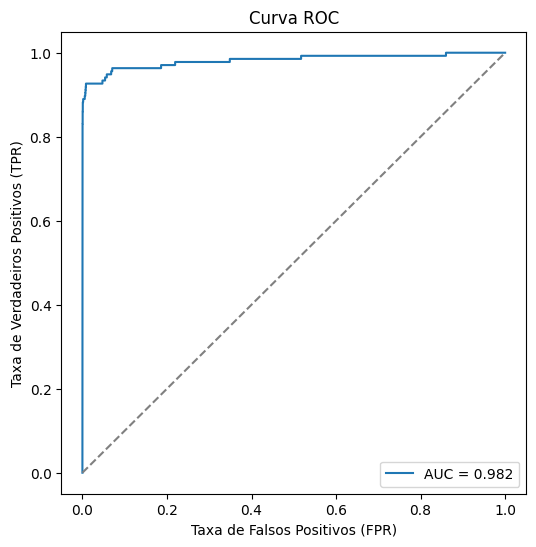

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades previstas pelo modelo
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Plotar
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")  # linha aleatória
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.show()


Precision Recall Curve

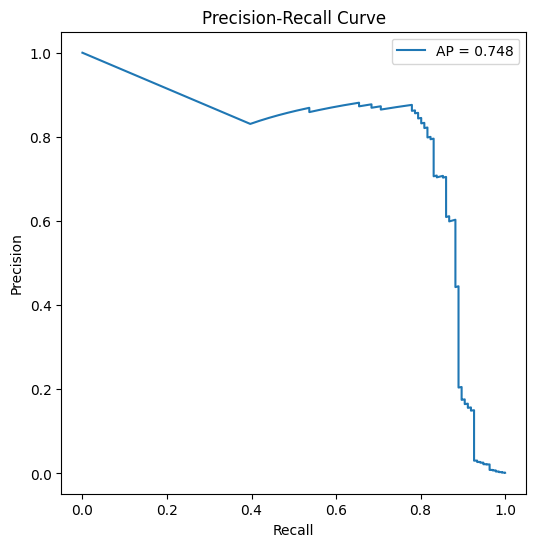

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Probabilidades previstas pelo modelo
y_pred_proba = model.predict_proba(X_test)[:,1]

# Calcular curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)

# Plotar
plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


Balanceamento de dados com Smote

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Separar features e target
X = df.drop("Class", axis=1)
y = df["Class"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Aplicar SMOTE no conjunto de treino
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Antes do SMOTE:", y_train.value_counts())
print("Depois do SMOTE:", y_train_resampled.value_counts())

# Treinar modelo com dados balanceados
model = LogisticRegression(max_iter=5000)
model.fit(X_train_resampled, y_train_resampled)

# Previsões
y_pred = model.predict(X_test)

# Métricas
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))


Antes do SMOTE: Class
0    199008
1       356
Name: count, dtype: int64
Depois do SMOTE: Class
0    199008
1    199008
Name: count, dtype: int64
Acurácia: 0.9903327364441792
Precisão: 0.13297872340425532
Recall: 0.9191176470588235
F1-Score: 0.23234200743494424


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Randon Florest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Treinar Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,       # número de árvores
    max_depth=None,         # profundidade ilimitada
    class_weight="balanced",# dá mais peso à classe minoritária
    random_state=42
)
rf_model.fit(X_train, y_train)

# Previsões
y_pred_rf = rf_model.predict(X_test)

# Métricas
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("Precisão:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))

# Importância das variáveis
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": importances})
print(feature_importance.sort_values(by="Importance", ascending=False).head(10))


Acurácia: 0.999602073897218
Precisão: 0.9553571428571429
Recall: 0.7867647058823529
F1-Score: 0.8629032258064516
   Feature  Importance
14     V14    0.176433
10     V10    0.108655
4       V4    0.105379
12     V12    0.103484
17     V17    0.090405
3       V3    0.059854
16     V16    0.047956
11     V11    0.046531
2       V2    0.036369
7       V7    0.026177


XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Converter para DMatrix (formato otimizado do XGBoost)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Parâmetros do modelo
params = {
    "objective": "binary:logistic",   # classificação binária
    "eval_metric": "logloss",         # métrica de avaliação
    "scale_pos_weight": len(y_train[y_train==0]) / len(y_train[y_train==1]), # balanceamento
    "max_depth": 6,                   # profundidade das árvores
    "eta": 0.1,                       # taxa de aprendizado
    "subsample": 0.8,                 # amostragem
    "colsample_bytree": 0.8           # amostragem de features
}

# Treinar modelo
bst = xgb.train(params, dtrain, num_boost_round=200)

# Previsões
y_pred_proba = bst.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)

# Métricas
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))


Acurácia: 0.999602073897218
Precisão: 0.8863636363636364
Recall: 0.8602941176470589
F1-Score: 0.8731343283582089


Ajuste de hiperparâmetros

In [ ]:
!pip install xgboost -q

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score
import numpy as np

# 2. Calcular a proporção de classes para lidar com dados desbalanceados
counter_neg = (y_train == 0).sum()
counter_pos = (y_train == 1).sum()
scale_pos_weight = counter_neg / counter_pos if counter_pos > 0 else 1

print(f"Proporção de classes (scale_pos_weight): {scale_pos_weight:.2f}")

# 3. Definir o modelo XGBoost
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",  # Usar algoritmo baseado em histogramas
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# 4. Definir espaço de hiperparâmetros otimizado
param_dist = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1, 0.2],  # Taxa de aprendizado
    "subsample": [0.7, 1.0],            # Porcentagem de amostragem das linhas
    "colsample_bytree": [0.7, 1.0]      # Porcentagem de amostragem das colunas
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,        # Testa apenas 10 combinações aleatórias
    cv=3,             # 3 Folds para validação cruzada
    scoring="f1",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("Iniciando a busca de hiperparâmetros...")
random_search.fit(X_train, y_train)

# 6. Exibir melhores resultados
print("\n--- Resultados da Otimização ---")
print("Melhores parâmetros encontrados:", random_search.best_params_)
print(f"Melhor F1-score de validação: {random_search.best_score_:.4f}")

# 7. Avaliar o melhor modelo no conjunto de teste (X_test, y_test)
best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)

print("\n--- Avaliação no Conjunto de Teste ---")
print(classification_report(y_test, y_pred))

Proporção de classes (scale_pos_weight): 559.01
Iniciando a busca de hiperparâmetros...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Resultados da Otimização ---
Melhores parâmetros encontrados: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
Melhor F1-score de validação: 0.8463

--- Avaliação no Conjunto de Teste ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.91      0.85      0.88       136

    accuracy                           1.00     85443
   macro avg       0.96      0.92      0.94     85443
weighted avg       1.00      1.00      1.00     85443



Explicabilidade SHAP

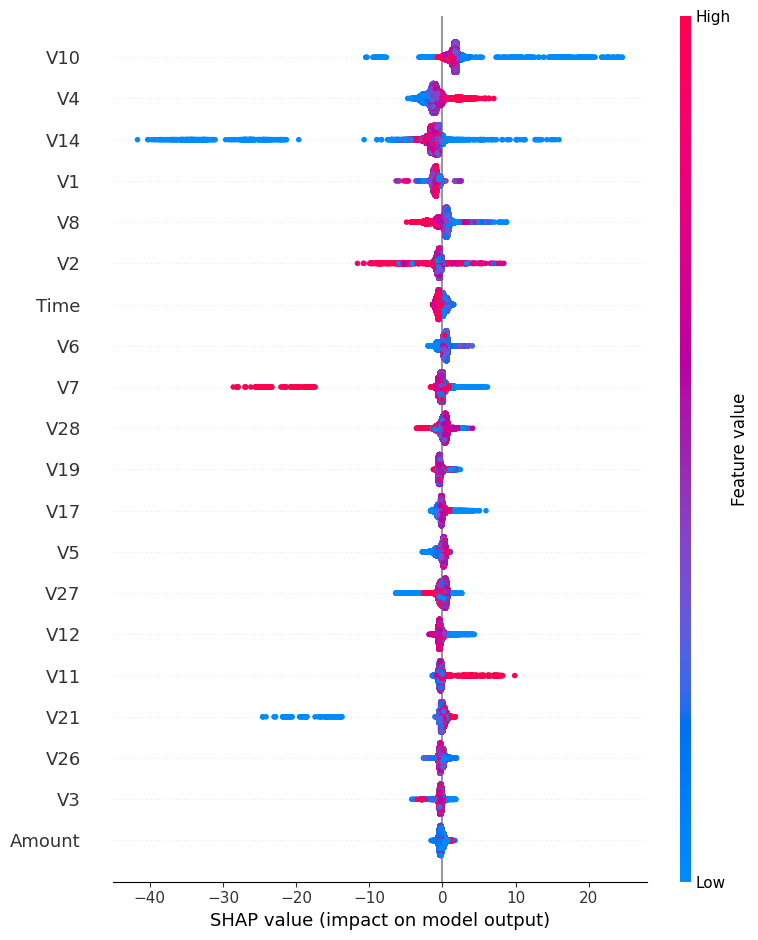

In [ ]:
import shap
shap.initjs()  # inicializa suporte a gráficos interativos


# Treinar modelo XGBoost
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, y_train)

# Criar explicador SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Gráfico global - importância das variáveis
shap.summary_plot(shap_values, X_test)

# Gráfico local - explicação de uma previsão específica
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])


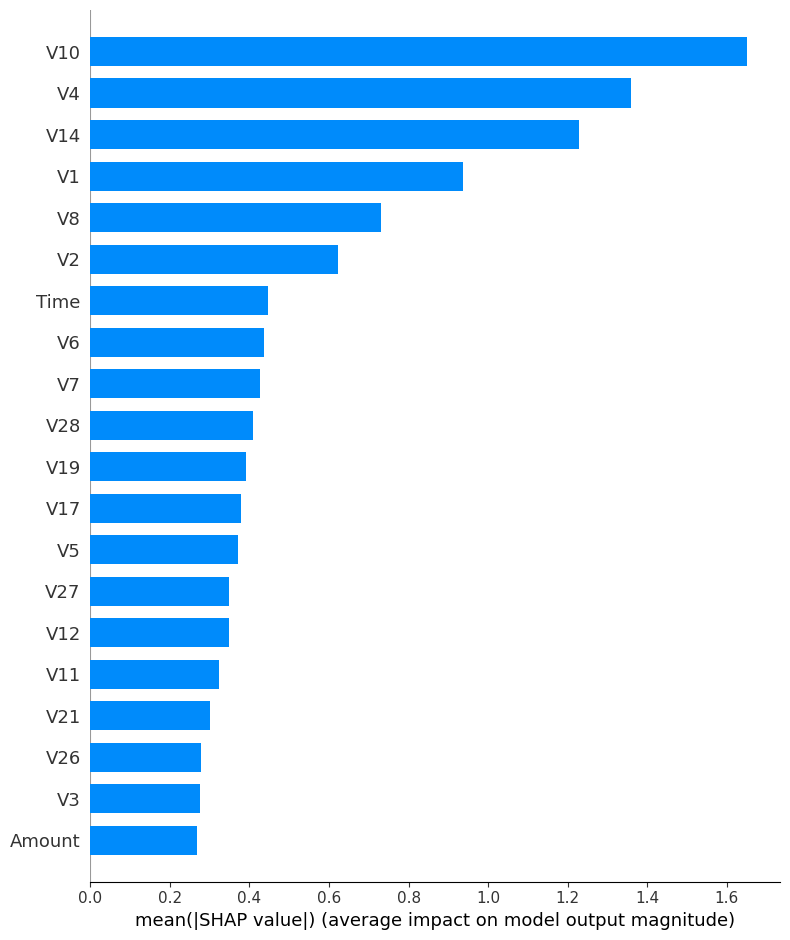

In [ ]:
import shap
import matplotlib.pyplot as plt

# Criar explicador SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Gráfico de barras verticais
shap.summary_plot(shap_values, X_test, plot_type="bar")
